# 4.4: Softmax Regression Implementation from Scratch

In [1]:
import torch
from d2l import torch as d2l

## 4.4.1: The Softmax

In [2]:
X=torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdims=True), X.sum(1, keepdims=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [3]:
def softmax(X):
    """
        Note: this is NOT robust against very large or small arguments.
        Thus, this code should not be used for any serious purposes.
    """
    X_exp = torch.exp(X) # exponentiate each term
    partition = X_exp.sum(1, keepdims=True) # row-wise sum
    return X_exp / partition # automatic broadcasting applied here

In [4]:
X = torch.rand((2,5))
X_prob = softmax(X)
X_prob, X_prob.sum(1) # sum(1) == sum across every row

(tensor([[0.2451, 0.1646, 0.1119, 0.2282, 0.2502],
         [0.1823, 0.1496, 0.2151, 0.2279, 0.2250]]),
 tensor([1.0000, 1.0000]))

## 4.4.2: The Model

In [5]:
class SoftmaxRegressionScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        # 10 classes, input is 28x28 pixel images => weights should be a 784x10 matrix, bias should be 1x10 row vector
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs), requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]

In [6]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def forward(self,X):
    X = X.reshape((-1, self.W.shape[0])) # flatten image matrix
    return softmax(torch.matmul(X, self.W) + self.b) 
        # REMEMBER: We batch calculations of o = x @ W + b using O=XW+b instead for softmax

## 4.4.3: The Cross-Entropy Loss

In [7]:
y=torch.tensor([0,2])
y_hat = torch.tensor([[0.1, 0.3, 0.6],  # Class 1
                      [0.3, 0.2, 0.5]]) # Class 2
y_hat[[0,1],y] # Indexing is much faster than for-loops in Python

tensor([0.1000, 0.5000])

In [8]:
def cross_entropy(y_hat, y):
    # Textbook formula doesn't take the average, but implementation does.
    # This is for consistency reasons (loss independent of batch size, inc. interpretability, enable hyperparam transfer, prevent gradient magnitude explosion in large batches)
    # print(list(range(len(y_hat)))) # Checks first dimension only
    return -torch.log(y_hat[list(range(len(y_hat))), y]).mean() 
cross_entropy(y_hat, y)

tensor(1.4979)

## 4.4.4: Training

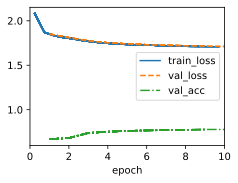

In [17]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

# 4.4.5: Prediction

In [18]:
X,y = next(iter(data.val_dataloader()))
preds = model(X).argmax(axis=1)
preds.shape

torch.Size([256])

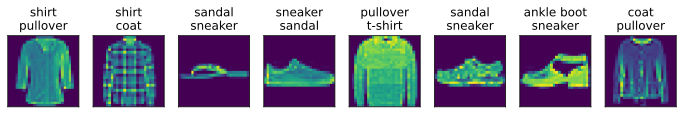

In [21]:
wrong = preds.type(y.dtype) != y
X,y,preds = X[wrong], y[wrong], preds[wrong]
labels = [a+'\n'+b for a,b, in zip(
    data.text_labels(y), data.text_labels(preds))]
data.visualize([X,y], labels=labels)

# 4.4.6: Summary

- This was SOTA in 1960/1970 statistical modeling
- Next section shows more effecient way of implementing this